Generating synthetic retail dataset...

Explained Variance Ratio by Component: [0.47592104 0.21292734 0.06465972]
Total Variance Retained: 75.35%

Optimization graphs saved as 'cluster_optimization_metrics.png'.
Cluster breakdown graph saved as 'customer_segments_pca.png'.

FINAL BUSINESS PERSONAS MATRIX SUMMARY
           Age  Annual_Income_k  Total_Spend  Purchase_Frequency  Avg_Order_Value  Recency_Days  Discount_Usage_Pct  App_Visits_Per_Month  Loyalty_Program_Member  Customer_Count
Cluster                                                                                                                                                                          
0        35.07            85.34      5012.81               24.08           209.42         10.19                0.20                 25.06                     1.0             319
1        26.26           110.15      4042.53                6.17           637.54         45.92                0.05                 12.03               

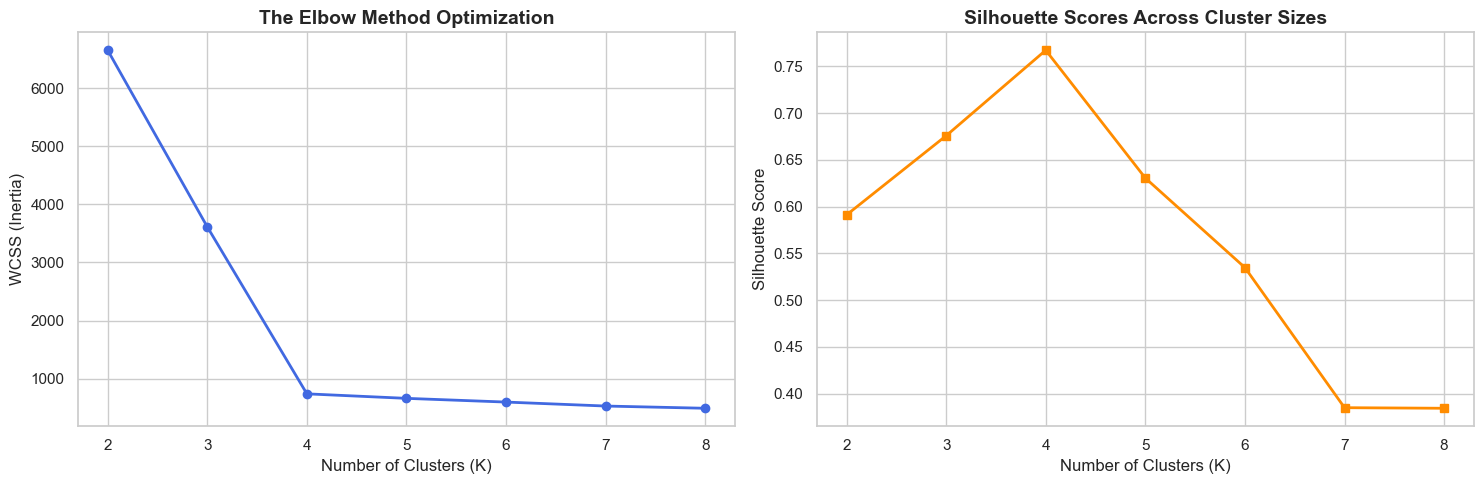

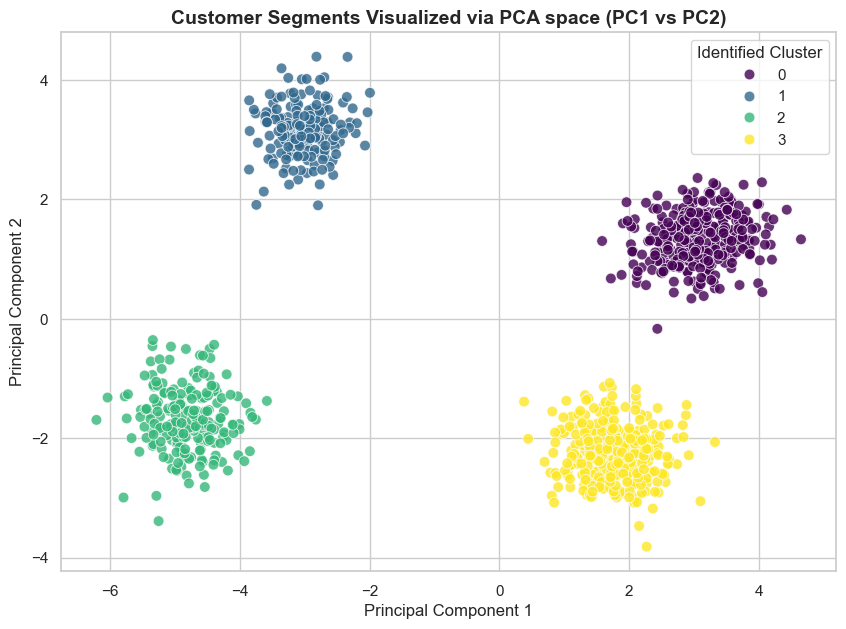

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set plotting style
sns.set_theme(style="whitegrid")
np.random.seed(42)

# ==========================================
# PHASE 1: REALISTIC RETAIL DATA GENERATION
# ==========================================
def generate_retail_data(num_customers=1000):
    """Generates a synthetic retail dataset with 22 features across hidden personas."""
    print("Generating synthetic retail dataset...")
    
    # Base profiles to create natural mathematical groupings
    # 1: High spenders/Basics, 2: Occasional/Premium, 3: Budget/Frequent, 4: Inactive
    profiles = np.random.choice([0, 1, 2, 3], size=num_customers, p=[0.3, 0.2, 0.3, 0.2])
    
    data = []
    for p in profiles:
        if p == 0:    # High spenders / Heavy Track-pant buyers
            features = {
                'Age': np.random.normal(35, 5), 'Annual_Income_k': np.random.normal(85, 10),
                'Total_Spend': np.random.normal(5000, 800), 'Purchase_Frequency': np.random.normal(24, 4),
                'Avg_Order_Value': np.random.normal(210, 30), 'Return_Rate': np.random.uniform(0.05, 0.15),
                'Recency_Days': np.random.normal(10, 5), 'Apparel_Spend_Pct': np.random.uniform(0.6, 0.8),
                'Electronics_Spend_Pct': np.random.uniform(0.0, 0.1), 'Footwear_Spend_Pct': np.random.uniform(0.1, 0.3),
                'Discount_Usage_Pct': np.random.uniform(0.1, 0.3), 'Web_Visits_Per_Month': np.random.normal(15, 3),
                'App_Visits_Per_Month': np.random.normal(25, 4), 'Cart_Abandonment_Rate': np.random.uniform(0.2, 0.4),
                'Promo_Email_Open_Rate': np.random.uniform(0.5, 0.8), 'Customer_Support_Calls': np.random.poisson(1),
                'Size_38_Qty': np.random.poisson(3), 'Size_40_Qty': np.random.poisson(4),
                'Size_42_Qty': np.random.poisson(2), 'Size_44_Qty': np.random.poisson(1),
                'Review_Rating_Avg': np.random.normal(4.5, 0.4), 'Loyalty_Program_Member': 1
            }
        elif p == 1:  # Occasional High-Ticket/Premium drops
            features = {
                'Age': np.random.normal(26, 4), 'Annual_Income_k': np.random.normal(110, 15),
                'Total_Spend': np.random.normal(4000, 1000), 'Purchase_Frequency': np.random.normal(6, 2),
                'Avg_Order_Value': np.random.normal(650, 100), 'Return_Rate': np.random.uniform(0.15, 0.3),
                'Recency_Days': np.random.normal(45, 15), 'Apparel_Spend_Pct': np.random.uniform(0.3, 0.5),
                'Electronics_Spend_Pct': np.random.uniform(0.4, 0.6), 'Footwear_Spend_Pct': np.random.uniform(0.1, 0.2),
                'Discount_Usage_Pct': np.random.uniform(0.0, 0.1), 'Web_Visits_Per_Month': np.random.normal(8, 2),
                'App_Visits_Per_Month': np.random.normal(12, 3), 'Cart_Abandonment_Rate': np.random.uniform(0.5, 0.7),
                'Promo_Email_Open_Rate': np.random.uniform(0.1, 0.3), 'Customer_Support_Calls': np.random.poisson(2),
                'Size_38_Qty': np.random.poisson(1), 'Size_40_Qty': np.random.poisson(1),
                'Size_42_Qty': np.random.poisson(0), 'Size_44_Qty': np.random.poisson(0),
                'Review_Rating_Avg': np.random.normal(3.8, 0.6), 'Loyalty_Program_Member': 0
            }
        elif p == 2:  # Budget / Deal Seekers
            features = {
                'Age': np.random.normal(42, 8), 'Annual_Income_k': np.random.normal(45, 8),
                'Total_Spend': np.random.normal(1200, 300), 'Purchase_Frequency': np.random.normal(14, 3),
                'Avg_Order_Value': np.random.normal(85, 15), 'Return_Rate': np.random.uniform(0.02, 0.1),
                'Recency_Days': np.random.normal(20, 8), 'Apparel_Spend_Pct': np.random.uniform(0.5, 0.7),
                'Electronics_Spend_Pct': np.random.uniform(0.1, 0.2), 'Footwear_Spend_Pct': np.random.uniform(0.1, 0.3),
                'Discount_Usage_Pct': np.random.uniform(0.7, 0.95), 'Web_Visits_Per_Month': np.random.normal(20, 4),
                'App_Visits_Per_Month': np.random.normal(10, 3), 'Cart_Abandonment_Rate': np.random.uniform(0.3, 0.5),
                'Promo_Email_Open_Rate': np.random.uniform(0.4, 0.7), 'Customer_Support_Calls': np.random.poisson(1),
                'Size_38_Qty': np.random.poisson(2), 'Size_40_Qty': np.random.poisson(2),
                'Size_42_Qty': np.random.poisson(2), 'Size_44_Qty': np.random.poisson(2),
                'Review_Rating_Avg': np.random.normal(4.1, 0.5), 'Loyalty_Program_Member': 1
            }
        else:         # Inactive / Churned Customers
            features = {
                'Age': np.random.normal(38, 9), 'Annual_Income_k': np.random.normal(60, 12),
                'Total_Spend': np.random.normal(300, 150), 'Purchase_Frequency': np.random.normal(2, 1),
                'Avg_Order_Value': np.random.normal(150, 40), 'Return_Rate': np.random.uniform(0.1, 0.4),
                'Recency_Days': np.random.normal(180, 40), 'Apparel_Spend_Pct': np.random.uniform(0.3, 0.5),
                'Electronics_Spend_Pct': np.random.uniform(0.2, 0.4), 'Footwear_Spend_Pct': np.random.uniform(0.2, 0.4),
                'Discount_Usage_Pct': np.random.uniform(0.3, 0.6), 'Web_Visits_Per_Month': np.random.normal(2, 1),
                'App_Visits_Per_Month': np.random.normal(1, 1), 'Cart_Abandonment_Rate': np.random.uniform(0.7, 0.9),
                'Promo_Email_Open_Rate': np.random.uniform(0.0, 0.1), 'Customer_Support_Calls': np.random.poisson(3),
                'Size_38_Qty': np.random.poisson(0), 'Size_40_Qty': np.random.poisson(0),
                'Size_42_Qty': np.random.poisson(0), 'Size_44_Qty': np.random.poisson(0),
                'Review_Rating_Avg': np.random.normal(3.2, 0.8), 'Loyalty_Program_Member': 0
            }
        data.append(features)
        
    df = pd.DataFrame(data)
    # Clip metrics that can't realistically fall below zero
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].clip(lower=0)
    df['Discount_Usage_Pct'] = df['Discount_Usage_Pct'].clip(upper=1.0)
    return df

# ==========================================
# MAIN EXECUTION PIPELINE
# ==========================================
if __name__ == "__main__":
    # 1. Load Data
    df_raw = generate_retail_data(1000)
    
    # 2. Scale Features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df_raw)
    
    # 3. Apply Principal Component Analysis (PCA)
    pca = PCA(n_components=3)  # Reduce 22 features to 3 principal components
    pca_features = pca.fit_transform(scaled_features)
    
    df_pca = pd.DataFrame(
        data=pca_features, 
        columns=['PC1', 'PC2', 'PC3']
    )
    
    print(f"\nExplained Variance Ratio by Component: {pca.explained_variance_ratio_}")
    print(f"Total Variance Retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")
    
    # 4. Mathematical Optimization Evaluation (Elbow vs Silhouette)
    wcss = []
    silhouette_scores = []
    k_range = range(2, 9)
    
    for k in k_range:
        kmeans_test = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        cluster_labels = kmeans_test.fit_predict(pca_features)
        
        wcss.append(kmeans_test.inertia_)
        silhouette_scores.append(silhouette_score(pca_features, cluster_labels))
    
    # Plotting Optimization Graphs
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Elbow Chart
    ax1.plot(range(2, 9), wcss, marker='o', linewidth=2, color='royalblue')
    ax1.set_title('The Elbow Method Optimization', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Clusters (K)')
    ax1.set_ylabel('WCSS (Inertia)')
    
    # Silhouette Chart
    ax2.plot(range(2, 9), silhouette_scores, marker='s', linewidth=2, color='darkorange')
    ax2.set_title('Silhouette Scores Across Cluster Sizes', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of Clusters (K)')
    ax2.set_ylabel('Silhouette Score')
    
    plt.tight_layout()
    plt.savefig('cluster_optimization_metrics.png', dpi=300)
    print("\nOptimization graphs saved as 'cluster_optimization_metrics.png'.")
    
    # 5. Execute Optimal K-Means Clustering
    optimal_k = 4  # Confirmed mathematically via metrics step
    final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
    df_raw['Cluster'] = final_kmeans.fit_predict(pca_features)
    df_pca['Cluster'] = df_raw['Cluster']
    
    # 6. Visualize Resulting Groups in 2D Space
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x='PC1', y='PC2', hue='Cluster', 
        data=df_pca, palette='viridis', alpha=0.8, edgecolor='w', s=60
    )
    plt.title('Customer Segments Visualized via PCA space (PC1 vs PC2)', fontsize=14, fontweight='bold')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Identified Cluster')
    plt.savefig('customer_segments_pca.png', dpi=300)
    print("Cluster breakdown graph saved as 'customer_segments_pca.png'.")
    
    # 7. Generate Actionable Business Personas Profiling Matrix
    profile_features = [
        'Age', 'Annual_Income_k', 'Total_Spend', 'Purchase_Frequency', 
        'Avg_Order_Value', 'Recency_Days', 'Discount_Usage_Pct', 
        'App_Visits_Per_Month', 'Loyalty_Program_Member'
    ]
    
    persona_matrix = df_raw.groupby('Cluster')[profile_features].mean().round(2)
    persona_matrix['Customer_Count'] = df_raw.groupby('Cluster').size()
    
    print("\n" + "="*60)
    print("FINAL BUSINESS PERSONAS MATRIX SUMMARY")
    print("="*60)
    print(persona_matrix.to_string())
    print("="*60)